In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel("image_classification (1).xlsx")

In [6]:
df.head(10)

,Image_ID,Brightness,Contrast,Edge_Count,Color_Variance,Object_Size_Pixels,Shape_Complexity,Texture_Score,Symmetry_Score,Noise_Level,Object_Class
0,IMG0001,218.8,56.9,338,29.2,2183,5.44,0.67,0.67,16.3,Dog
1,IMG0002,186.4,5.9,203,92.4,2140,0.87,0.52,0.16,49.2,Person
2,IMG0003,241.4,63.3,165,23.0,4634,0.28,0.64,0.49,33.4,Person
3,IMG0004,199.3,76.9,30,28.9,1852,1.11,0.34,0.74,2.2,Person
4,IMG0005,80.0,99.4,125,36.9,1715,4.16,0.91,0.87,16.3,Cat
5,IMG0006,63.2,1.1,305,66.4,1949,9.34,0.59,0.63,31.2,Dog
6,IMG0007,177.9,73.0,216,11.8,2742,6.41,0.09,0.67,2.8,Dog
7,IMG0008,92.8,57.2,67,95.4,1700,8.04,0.45,0.13,1.2,Dog
8,IMG0009,144.4,43.4,455,86.6,3496,4.72,0.76,0.95,22.5,Car
9,IMG0010,1.6,12.8,440,57.7,4502,3.68,0.79,0.13,16.6,Car


In [8]:
print(df.shape)

(500, 11)


In [10]:
print(df.columns)

Index(['Image_ID', 'Brightness', 'Contrast', 'Edge_Count', 'Color_Variance',
       'Object_Size_Pixels', 'Shape_Complexity', 'Texture_Score',
       'Symmetry_Score', 'Noise_Level', 'Object_Class'],
      dtype='str')


In [12]:
columns = pd.DataFrame(df.columns, columns=["columns name"])
display(columns)

,columns name
0,Image_ID
1,Brightness
2,Contrast
3,Edge_Count
4,Color_Variance
5,Object_Size_Pixels
6,Shape_Complexity
7,Texture_Score
8,Symmetry_Score
9,Noise_Level


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Image_ID            500 non-null    str    
 1   Brightness          500 non-null    float64
 2   Contrast            500 non-null    float64
 3   Edge_Count          500 non-null    int64  
 4   Color_Variance      500 non-null    float64
 5   Object_Size_Pixels  500 non-null    int64  
 6   Shape_Complexity    500 non-null    float64
 7   Texture_Score       500 non-null    float64
 8   Symmetry_Score      500 non-null    float64
 9   Noise_Level         500 non-null    float64
 10  Object_Class        500 non-null    str    
dtypes: float64(7), int64(2), str(2)
memory usage: 43.1 KB


In [14]:
df.isnull().sum

<bound method DataFrame.sum of      Image_ID  Brightness  Contrast  Edge_Count  Color_Variance  \
0       False       False     False       False           False   
1       False       False     False       False           False   
2       False       False     False       False           False   
3       False       False     False       False           False   
4       False       False     False       False           False   
..        ...         ...       ...         ...             ...   
495     False       False     False       False           False   
496     False       False     False       False           False   
497     False       False     False       False           False   
498     False       False     False       False           False   
499     False       False     False       False           False   

     Object_Size_Pixels  Shape_Complexity  Texture_Score  Symmetry_Score  \
0                 False             False          False           False   
1           

In [15]:
df.describe()

,Brightness,Contrast,Edge_Count,Color_Variance,Object_Size_Pixels,Shape_Complexity,Texture_Score,Symmetry_Score,Noise_Level
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,123.906600,49.275200,243.084000,49.580800,2535.900000,4.970080,0.49142,0.491180,24.040200
std,74.652814,28.489563,140.240935,29.448559,1413.412629,2.868417,0.28988,0.280731,14.421187
min,0.000000,0.100000,6.000000,0.200000,112.000000,0.160000,0.00000,0.000000,0.000000
25%,57.350000,24.375000,123.000000,24.925000,1315.750000,2.502500,0.24000,0.250000,11.575000
50%,124.100000,49.700000,248.000000,49.950000,2368.000000,5.065000,0.47000,0.490000,23.750000
75%,188.375000,73.625000,361.000000,75.125000,3843.000000,7.452500,0.76250,0.710000,36.400000
max,254.200000,99.500000,492.000000,99.900000,4998.000000,9.990000,1.00000,1.000000,49.800000


In [16]:
class_count=df["Object_Class"].value_counts()
display(class_count)

Object_Class
Dog       165
Person    150
Car       127
Cat        58
Name: count, dtype: int64

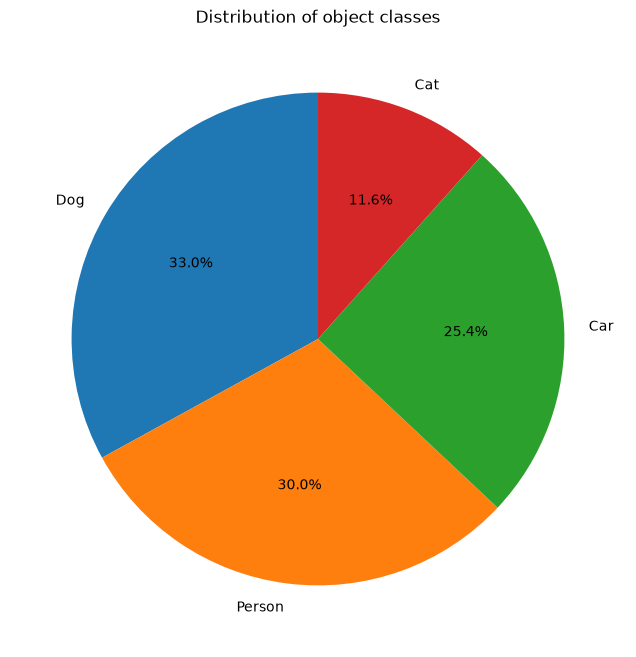

In [18]:
plt.figure(figsize=(8,8))
plt.pie(
    class_count,
    labels=class_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of object classes")
plt.show()

In [19]:
print("Highest Class:")

print(class_count.idxmax())

print("Count:")

print(class_count.max())

print()

print("Lowest Class:")

print(class_count.idxmin())

print("Count:")

print(class_count.min())

Highest Class:
Dog
Count:
165

Lowest Class:
Cat
Count:
58


In [4]:
df[["Object_Class", "Brightness", "Contrast", "Object_Size_Pixels"]]

,Object_Class,Brightness,Contrast,Object_Size_Pixels
0,Dog,218.8,56.9,2183
1,Person,186.4,5.9,2140
2,Person,241.4,63.3,4634
3,Person,199.3,76.9,1852
4,Cat,80.0,99.4,1715
...,...,...,...,...
495,Dog,227.0,61.9,1038
496,Cat,166.3,48.0,1736
497,Cat,117.2,66.2,2824
498,Dog,172.3,21.9,2610


In [5]:
grouped = df.groupby("Object_Class")

In [8]:
comparison = grouped[["Brightness",
                      "Contrast",
                      "Object_Size_Pixels"]].mean()
comparison = comparison.round(2)
display(comparison)

,Brightness,Contrast,Object_Size_Pixels
Object_Class,,,
Car,125.84,47.56,4123.01
Cat,125.77,50.61,1707.93
Dog,128.66,47.35,1536.56
Person,116.33,52.33,2611.57


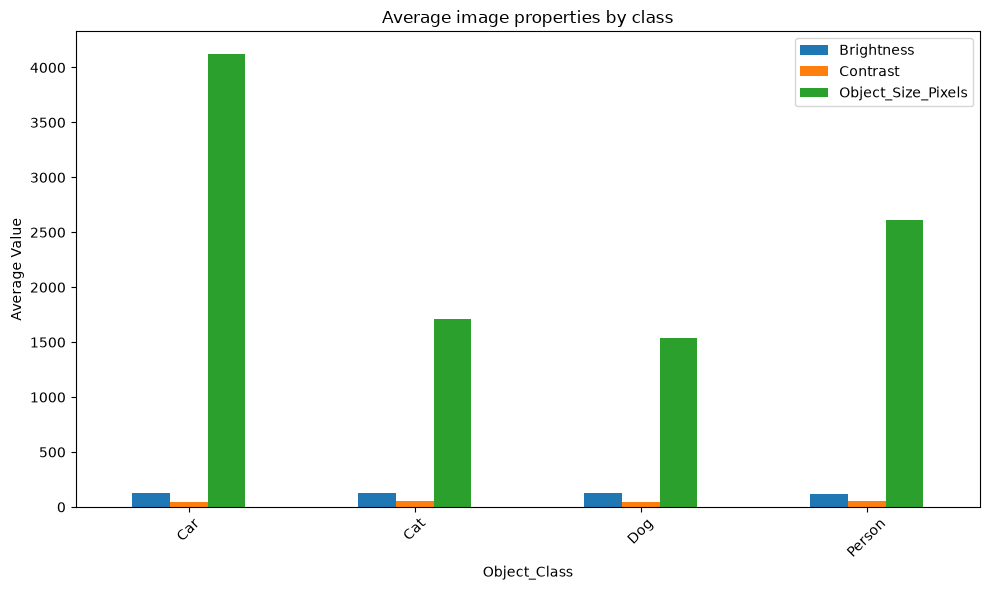

In [9]:
comparison.plot(kind="bar", figsize=(10,6))
plt.xlabel("Object_Class")
plt.ylabel("Average Value")
plt.title("Average image properties by class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

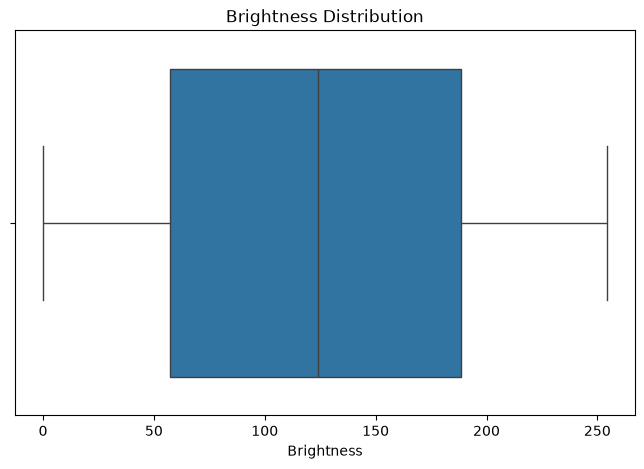

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Brightness"])
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.show()

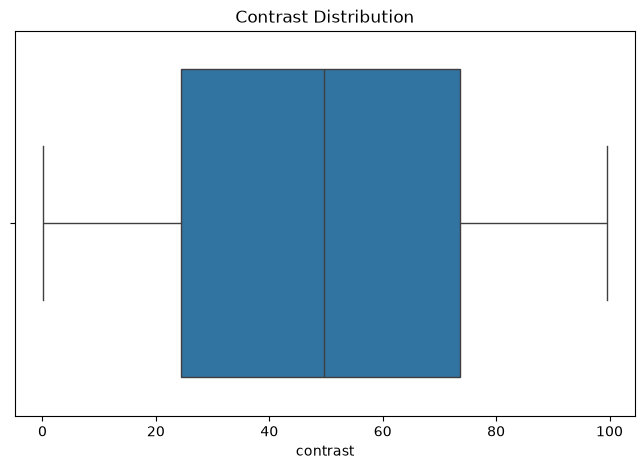

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Contrast"])
plt.title("Contrast Distribution")
plt.xlabel("contrast")
plt.show()


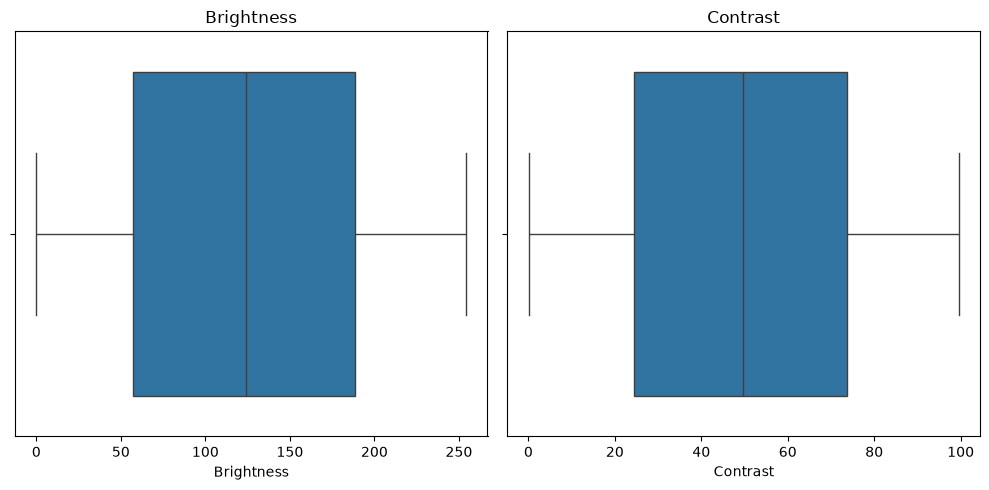

In [16]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

sns.boxplot(x=df["Brightness"])

plt.title("Brightness")

plt.subplot(1,2,2)

sns.boxplot(x=df["Contrast"])

plt.title("Contrast")

plt.tight_layout()

plt.show()

In [7]:
Q1 = df["Brightness"].quantile(0.25)
print(Q1)

57.35


In [9]:
Q3 = df["Brightness"].quantile(0.75)
print(Q3)

188.375


In [11]:
IQR = Q3 - Q1
print(IQR)

131.025


In [13]:
lower_limit = Q1 - 1.5 * IQR
print(lower_limit)

-139.18750000000003


In [14]:
upper_limit = Q3 + 1.5 * IQR
print(upper_limit)

384.9125


In [16]:
outlier = df[(df["Brightness"] < lower_limit) | (df["Brightness"] > upper_limit)]
display(outlier)

,Image_ID,Brightness,Contrast,Edge_Count,Color_Variance,Object_Size_Pixels,Shape_Complexity,Texture_Score,Symmetry_Score,Noise_Level,Object_Class


In [17]:
print("Total_outlier")
print(len(outlier))

Total_outlier
0


In [21]:
num_df = df.select_dtypes("number")
display(num_df.head())

,Brightness,Contrast,Edge_Count,Color_Variance,Object_Size_Pixels,Shape_Complexity,Texture_Score,Symmetry_Score,Noise_Level
0,218.8,56.9,338,29.2,2183,5.44,0.67,0.67,16.3
1,186.4,5.9,203,92.4,2140,0.87,0.52,0.16,49.2
2,241.4,63.3,165,23.0,4634,0.28,0.64,0.49,33.4
3,199.3,76.9,30,28.9,1852,1.11,0.34,0.74,2.2
4,80.0,99.4,125,36.9,1715,4.16,0.91,0.87,16.3


In [22]:
corr_matrix = num_df.corr()
display(corr_matrix.round(2))

,Brightness,Contrast,Edge_Count,Color_Variance,Object_Size_Pixels,Shape_Complexity,Texture_Score,Symmetry_Score,Noise_Level
Brightness,1.00,0.06,0.03,-0.02,-0.06,0.03,-0.02,-0.03,0.03
Contrast,0.06,1.00,0.02,0.02,0.02,-0.01,0.04,0.02,-0.03
Edge_Count,0.03,0.02,1.00,-0.01,0.05,0.04,0.02,-0.01,0.01
Color_Variance,-0.02,0.02,-0.01,1.00,-0.05,-0.03,-0.04,0.07,-0.03
Object_Size_Pixels,-0.06,0.02,0.05,-0.05,1.00,-0.01,0.12,-0.05,-0.04
Shape_Complexity,0.03,-0.01,0.04,-0.03,-0.01,1.00,0.02,-0.03,0.02
Texture_Score,-0.02,0.04,0.02,-0.04,0.12,0.02,1.00,-0.04,0.05
Symmetry_Score,-0.03,0.02,-0.01,0.07,-0.05,-0.03,-0.04,1.00,-0.02
Noise_Level,0.03,-0.03,0.01,-0.03,-0.04,0.02,0.05,-0.02,1.00


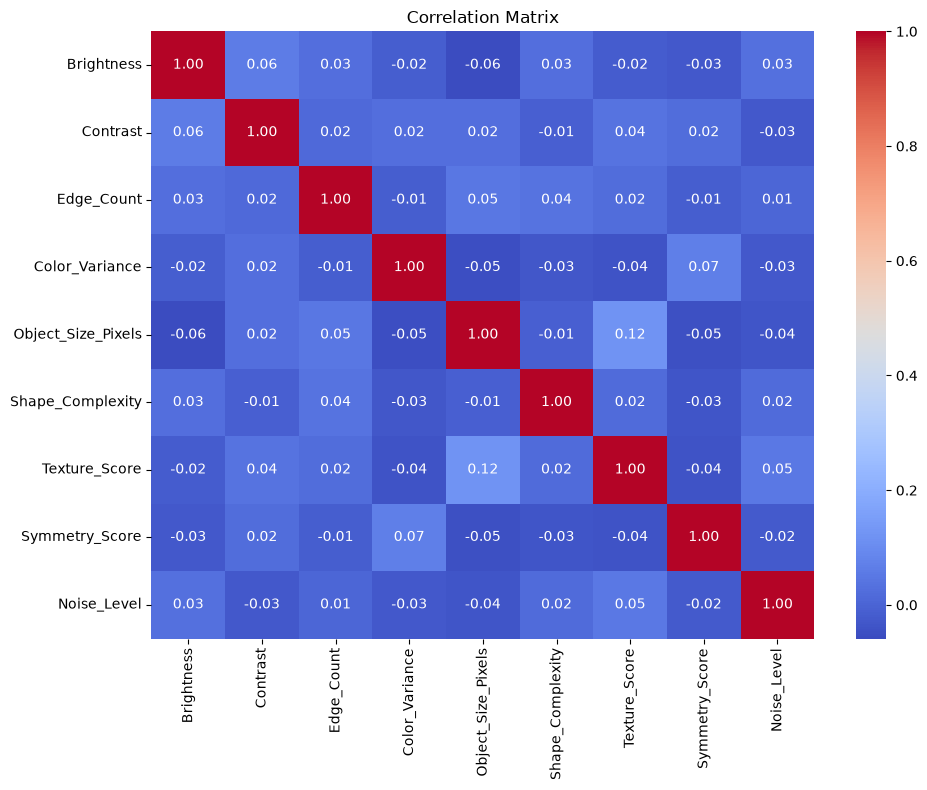

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [24]:
corr_matrix = num_df.corr()
corr_pair = corr_matrix.unstack()
corr_pair = corr_pair.sort_values(ascending=False)
display(corr_pair.head(15))

Brightness          Brightness            1.000000
Contrast            Contrast              1.000000
Texture_Score       Texture_Score         1.000000
Noise_Level         Noise_Level           1.000000
Symmetry_Score      Symmetry_Score        1.000000
Shape_Complexity    Shape_Complexity      1.000000
Object_Size_Pixels  Object_Size_Pixels    1.000000
Color_Variance      Color_Variance        1.000000
Edge_Count          Edge_Count            1.000000
Object_Size_Pixels  Texture_Score         0.122946
Texture_Score       Object_Size_Pixels    0.122946
Color_Variance      Symmetry_Score        0.068934
Symmetry_Score      Color_Variance        0.068934
Contrast            Brightness            0.058011
Brightness          Contrast              0.058011
dtype: float64

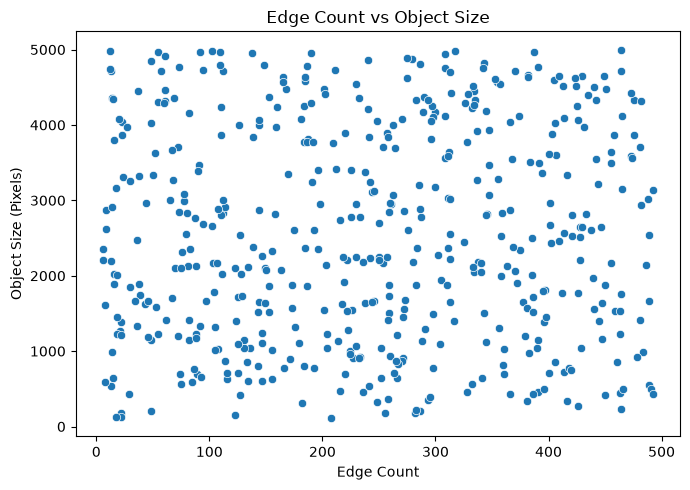

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(data =df, x ="Edge_Count", y = "Object_Size_Pixels")
plt.title("Edge Count vs Object Size")
plt.xlabel("Edge Count")
plt.ylabel("Object Size (Pixels)")
plt.tight_layout()
plt.show()

In [27]:
correlation = df["Edge_Count"].corr(df["Object_Size_Pixels"])

print("Correlation:", round(correlation,2))

Correlation: 0.05


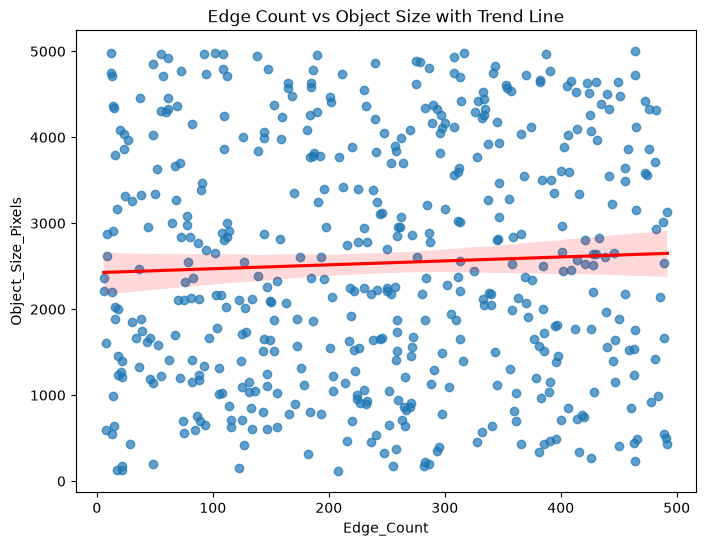

In [28]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Edge_Count",
    y="Object_Size_Pixels",
    scatter_kws={"alpha":0.7},
    line_kws={"color":"red"}
)

plt.title("Edge Count vs Object Size with Trend Line")

plt.show()

In [3]:
correlation = df["Edge_Count"].corr(df["Object_Size_Pixels"])

print("Correlation:", round(correlation, 2))

Correlation: 0.05


In [7]:
group = df.groupby("Object_Class")
result = group[["Symmetry_Score",
                "Texture_Score"]].mean()
display(result.round(2))

,Symmetry_Score,Texture_Score
Object_Class,,
Car,0.48,0.51
Cat,0.86,0.50
Dog,0.36,0.48
Person,0.50,0.48


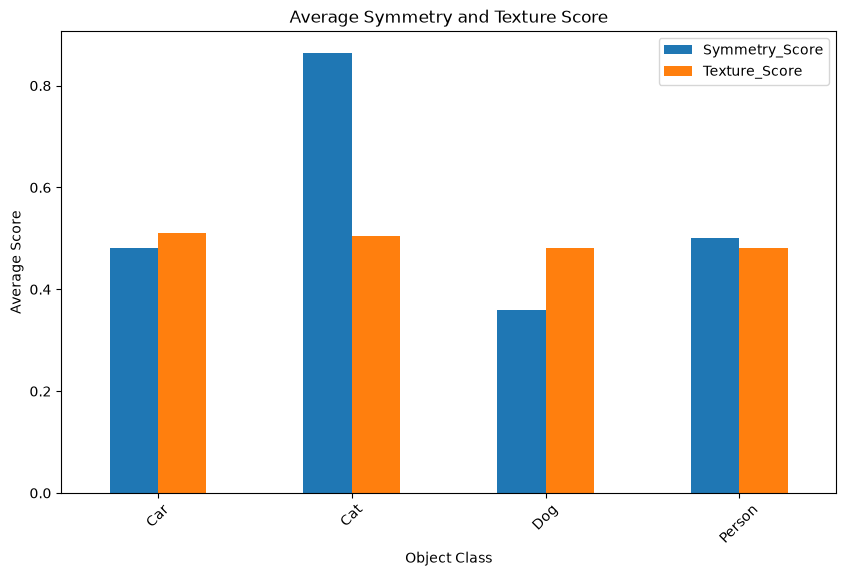

In [8]:
result.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Symmetry and Texture Score")

plt.xlabel("Object Class")

plt.ylabel("Average Score")

plt.xticks(rotation=45)

plt.show()

In [9]:
highest = result["Symmetry_Score"].idxmax()

print("Most Symmetric Object Class:")

print(highest)

Most Symmetric Object Class:
Cat


In [12]:
noise = df.groupby("Object_Class")["Noise_Level"].mean()
display(noise.round(2))

Object_Class
Car       24.47
Cat       19.40
Dog       24.52
Person    24.94
Name: Noise_Level, dtype: float64

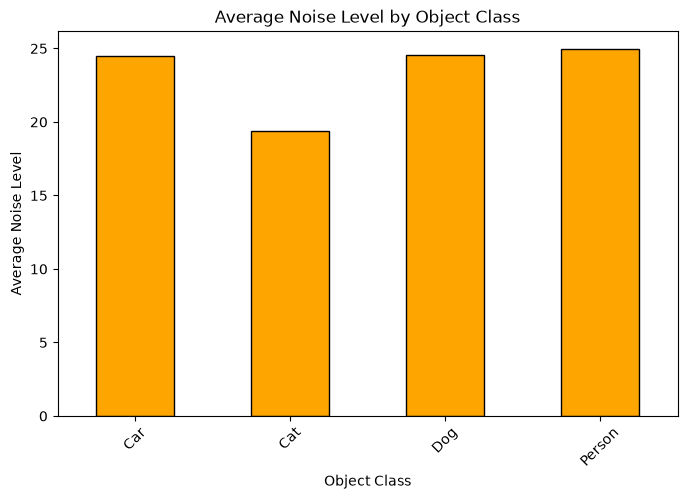

In [14]:
plt.figure(figsize=(8,5))

noise.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Average Noise Level by Object Class")

plt.xlabel("Object Class")

plt.ylabel("Average Noise Level")

plt.xticks(rotation=45)

plt.show()

In [16]:
print("Object Class with Highest Noise:")

print(noise.idxmax())

print()

print("Highest Average Noise Level:")

print(noise.max().round(2))

Object Class with Highest Noise:
Person

Highest Average Noise Level:
24.94


In [17]:
df[["Image_ID", "Object_Class", "Object_Size_Pixels"]]

,Image_ID,Object_Class,Object_Size_Pixels
0,IMG0001,Dog,2183
1,IMG0002,Person,2140
2,IMG0003,Person,4634
3,IMG0004,Person,1852
4,IMG0005,Cat,1715
...,...,...,...
495,IMG0496,Dog,1038
496,IMG0497,Cat,1736
497,IMG0498,Cat,2824
498,IMG0499,Dog,2610


In [19]:
largest_objects = df.sort_values(
    by="Object_Size_Pixels",
    ascending=False
)
display(largest_objects.head(10))

,Image_ID,Brightness,Contrast,Edge_Count,Color_Variance,Object_Size_Pixels,Shape_Complexity,Texture_Score,Symmetry_Score,Noise_Level,Object_Class
239,IMG0240,59.3,47.4,464,13.9,4998,3.45,0.08,0.63,1.6,Car
178,IMG0179,32.5,87.1,12,38.9,4986,3.68,0.77,0.97,11.2,Car
27,IMG0028,159.7,4.3,102,36.0,4980,8.38,0.30,0.58,32.1,Car
236,IMG0237,78.4,41.6,317,72.2,4976,5.09,0.58,0.19,17.9,Car
215,IMG0216,118.3,7.1,55,0.8,4969,9.80,0.45,0.47,24.7,Car
351,IMG0352,82.4,21.2,92,40.8,4968,0.20,0.83,0.50,11.0,Person
164,IMG0165,213.6,32.8,387,23.6,4968,3.57,0.96,0.16,46.8,Car
451,IMG0452,14.1,87.7,109,67.3,4964,0.96,0.48,0.12,5.3,Person
292,IMG0293,42.3,87.7,190,55.4,4956,4.42,0.62,0.47,47.0,Car
63,IMG0064,139.1,80.8,138,45.7,4949,1.64,0.74,0.54,33.9,Person
